# 📊 Complete Performance Metrics — AI Visual Search
### Confusion Matrix · F1 · Precision · Recall · ROC · PR Curve · MRR · MAP

| Metric | What it measures |
|--------|----------------|
| **Confusion Matrix** | Which classes get confused with each other |
| **Precision@K** | Of top-K retrieved, how many are correct |
| **Recall@K** | Of all correct images, how many retrieved in top-K |
| **F1 Score** | Harmonic mean of Precision & Recall |
| **MAP** | Mean Average Precision across all queries |
| **MRR** | Mean Reciprocal Rank — how high is the first correct result |
| **ROC + AUC** | True positive vs false positive rate |
| **PR Curve** | Precision-Recall trade-off |
| **Top-K Accuracy** | Is correct class in top-K predictions |

> ✅ Run this **after** `real_comparison.ipynb` — reuses saved `.pickle` feature files
---

## Step 1 — Install & Imports

In [1]:
!pip install faiss-cpu scikit-learn matplotlib seaborn --quiet

from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.6 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive mounted


In [2]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve,
    top_k_accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
import faiss

sns.set_theme(style='whitegrid', font_scale=1.05)
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

print('✅ Imports done')

✅ Imports done


---
## Step 2 — Load Saved Features

In [3]:
FEATURES_DIR = '/content/drive/MyDrive/features'
RESULTS_DIR  = '/content/drive/MyDrive/metrics'
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAMES = ['resnet50','vgg16','vgg19','mobilenet','inception_v3','xception']

ALL_FEATURES  = {}
ALL_CLASSES   = {}

# Load class_ids (same for all models)
cls_path  = f'{FEATURES_DIR}/class_ids.pickle'
CLASS_IDS = pickle.load(open(cls_path, 'rb'))
N_CLASSES = len(np.unique(CLASS_IDS))
N_IMAGES  = len(CLASS_IDS)

# Load features for each model
for name in MODEL_NAMES:
    path = f'{FEATURES_DIR}/features-{name}.pickle'
    if os.path.exists(path):
        feats = pickle.load(open(path, 'rb'))
        ALL_FEATURES[name] = feats
        ALL_CLASSES[name]  = CLASS_IDS
        print(f'  ✅ {name:15s}  shape={feats.shape}')
    else:
        print(f'  ❌ {name} not found — run real_comparison.ipynb first')

print(f'\nTotal images : {N_IMAGES}')
print(f'Total classes: {N_CLASSES}')

  ✅ resnet50         shape=(9144, 2048)
  ✅ vgg16            shape=(9144, 512)
  ✅ vgg19            shape=(9144, 512)
  ✅ mobilenet        shape=(9144, 1024)
  ✅ inception_v3     shape=(9144, 2048)
  ✅ xception         shape=(9144, 2048)

Total images : 9144
Total classes: 102


---
## Step 3 — KNN Classifier (needed for Confusion Matrix & F1)
> We use K-Nearest Neighbors on feature embeddings to assign class labels — this is exactly how the retrieval system works

In [5]:
from sklearn.model_selection import train_test_split

def get_knn_predictions(features, class_ids, k=5, test_size=0.2):
    """
    Split features into train/test.
    Train KNN on train set, predict on test set.
    Returns (y_true, y_pred, y_proba).
    """
    # Normalize features
    feats = features.astype('float32')
    norms = np.linalg.norm(feats, axis=1, keepdims=True)
    feats = feats / (norms + 1e-9)

    X_train, X_test, y_train, y_test = train_test_split(
        feats, class_ids,
        test_size=test_size,
        random_state=42,
        stratify=class_ids
    )

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='cosine',
        algorithm='brute',
        n_jobs=-1
    )
    knn.fit(X_train, y_train)

    y_pred  = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)   # shape: (n_test, n_classes)

    return y_test, y_pred, y_proba, knn.classes_


# Run KNN for ALL models — store results
KNN_RESULTS = {}
print('🔄 Running KNN classifier (train/test split 80/20) ...\n')

for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    y_true, y_pred, y_proba, classes = get_knn_predictions(
        ALL_FEATURES[name], CLASS_IDS, k=5
    )
    acc = np.mean(y_true == y_pred)
    KNN_RESULTS[name] = {
        'y_true':  y_true,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'classes': classes,
        'accuracy': acc,
    }
    print(f'accuracy={acc:.4f}')

print('\n✅ Done')

🔄 Running KNN classifier (train/test split 80/20) ...

  resnet50 ... accuracy=0.8956
  vgg16 ... accuracy=0.8732
  vgg19 ... accuracy=0.8650
  mobilenet ... accuracy=0.8212
  inception_v3 ... accuracy=0.8819
  xception ... accuracy=0.8721

✅ Done


---
## Step 4 — Metric 1: Classification Report (Precision · Recall · F1 per class)

In [6]:
print('=' * 65)
print('  CLASSIFICATION REPORT — All Models (macro average)')
print('=' * 65)

summary_rows = []
for name in MODEL_NAMES:
    r    = KNN_RESULTS[name]
    p    = precision_score(r['y_true'], r['y_pred'], average='macro', zero_division=0)
    rec  = recall_score(   r['y_true'], r['y_pred'], average='macro', zero_division=0)
    f1   = f1_score(       r['y_true'], r['y_pred'], average='macro', zero_division=0)
    f1w  = f1_score(       r['y_true'], r['y_pred'], average='weighted', zero_division=0)
    acc  = r['accuracy']

    summary_rows.append({
        'Model':              name,
        'Accuracy':           round(acc,  4),
        'Macro Precision':    round(p,    4),
        'Macro Recall':       round(rec,  4),
        'Macro F1':           round(f1,   4),
        'Weighted F1':        round(f1w,  4),
    })
    print(f'\n  ── {name.upper()} ──')
    print(f'     Accuracy         : {acc:.4f}')
    print(f'     Macro Precision  : {p:.4f}')
    print(f'     Macro Recall     : {rec:.4f}')
    print(f'     Macro F1         : {f1:.4f}')
    print(f'     Weighted F1      : {f1w:.4f}')

df_summary = pd.DataFrame(summary_rows).set_index('Model')

print('\n\n=== Summary Table ===')
display(df_summary.style
    .background_gradient(subset=['Accuracy'],        cmap='YlGn')
    .background_gradient(subset=['Macro F1'],        cmap='Blues')
    .background_gradient(subset=['Macro Recall'],    cmap='Greens')
    .background_gradient(subset=['Macro Precision'], cmap='Oranges')
    .format('{:.4f}')
    .set_caption('KNN Classification — Macro Averaged Metrics')
)

  CLASSIFICATION REPORT — All Models (macro average)

  ── RESNET50 ──
     Accuracy         : 0.8956
     Macro Precision  : 0.8822
     Macro Recall     : 0.8730
     Macro F1         : 0.8690
     Weighted F1      : 0.8932

  ── VGG16 ──
     Accuracy         : 0.8732
     Macro Precision  : 0.8581
     Macro Recall     : 0.8400
     Macro F1         : 0.8342
     Weighted F1      : 0.8688

  ── VGG19 ──
     Accuracy         : 0.8650
     Macro Precision  : 0.8474
     Macro Recall     : 0.8346
     Macro F1         : 0.8283
     Weighted F1      : 0.8608

  ── MOBILENET ──
     Accuracy         : 0.8212
     Macro Precision  : 0.8648
     Macro Recall     : 0.7600
     Macro F1         : 0.7846
     Weighted F1      : 0.8258

  ── INCEPTION_V3 ──
     Accuracy         : 0.8819
     Macro Precision  : 0.8717
     Macro Recall     : 0.8724
     Macro F1         : 0.8653
     Weighted F1      : 0.8786

  ── XCEPTION ──
     Accuracy         : 0.8721
     Macro Precision  : 0.8655
   

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,
resnet50,0.8956,0.8822,0.8730,0.8690,0.8932
vgg16,0.8732,0.8581,0.8400,0.8342,0.8688
vgg19,0.8650,0.8474,0.8346,0.8283,0.8608
mobilenet,0.8212,0.8648,0.7600,0.7846,0.8258
inception_v3,0.8819,0.8717,0.8724,0.8653,0.8786
xception,0.8721,0.8655,0.8547,0.8518,0.8708


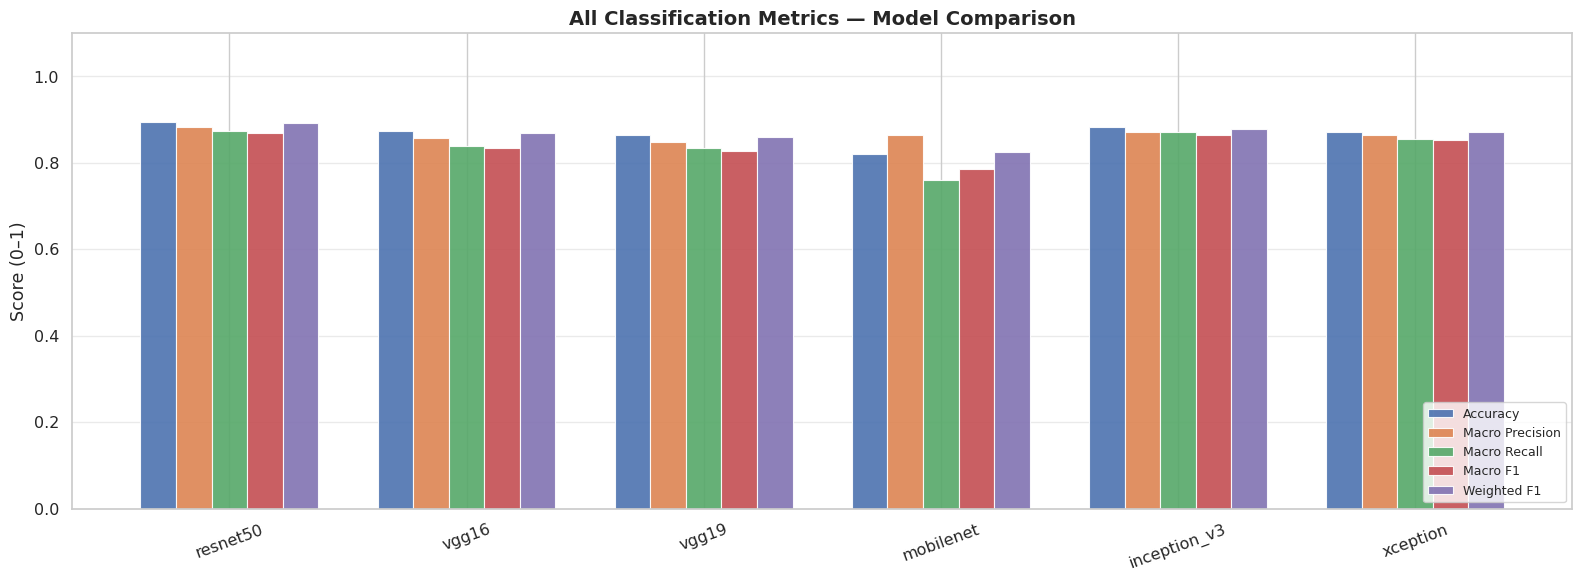

💾 Saved: 01_all_metrics.png


In [7]:
# ── Plot: All metrics side-by-side ────────────────────────────────────────
metrics_to_plot = ['Accuracy','Macro Precision','Macro Recall','Macro F1','Weighted F1']
x     = np.arange(len(MODEL_NAMES))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
    vals = df_summary[metric].values
    bars = ax.bar(x + i*width, vals, width,
                  label=metric, color=color, edgecolor='white',
                  linewidth=0.8, alpha=0.9)

ax.set_title('All Classification Metrics — Model Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(MODEL_NAMES, rotation=20)
ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/01_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 01_all_metrics.png')

---
## Step 5 — Metric 2: Confusion Matrix (Best Model & All Models)

Best model: resnet50


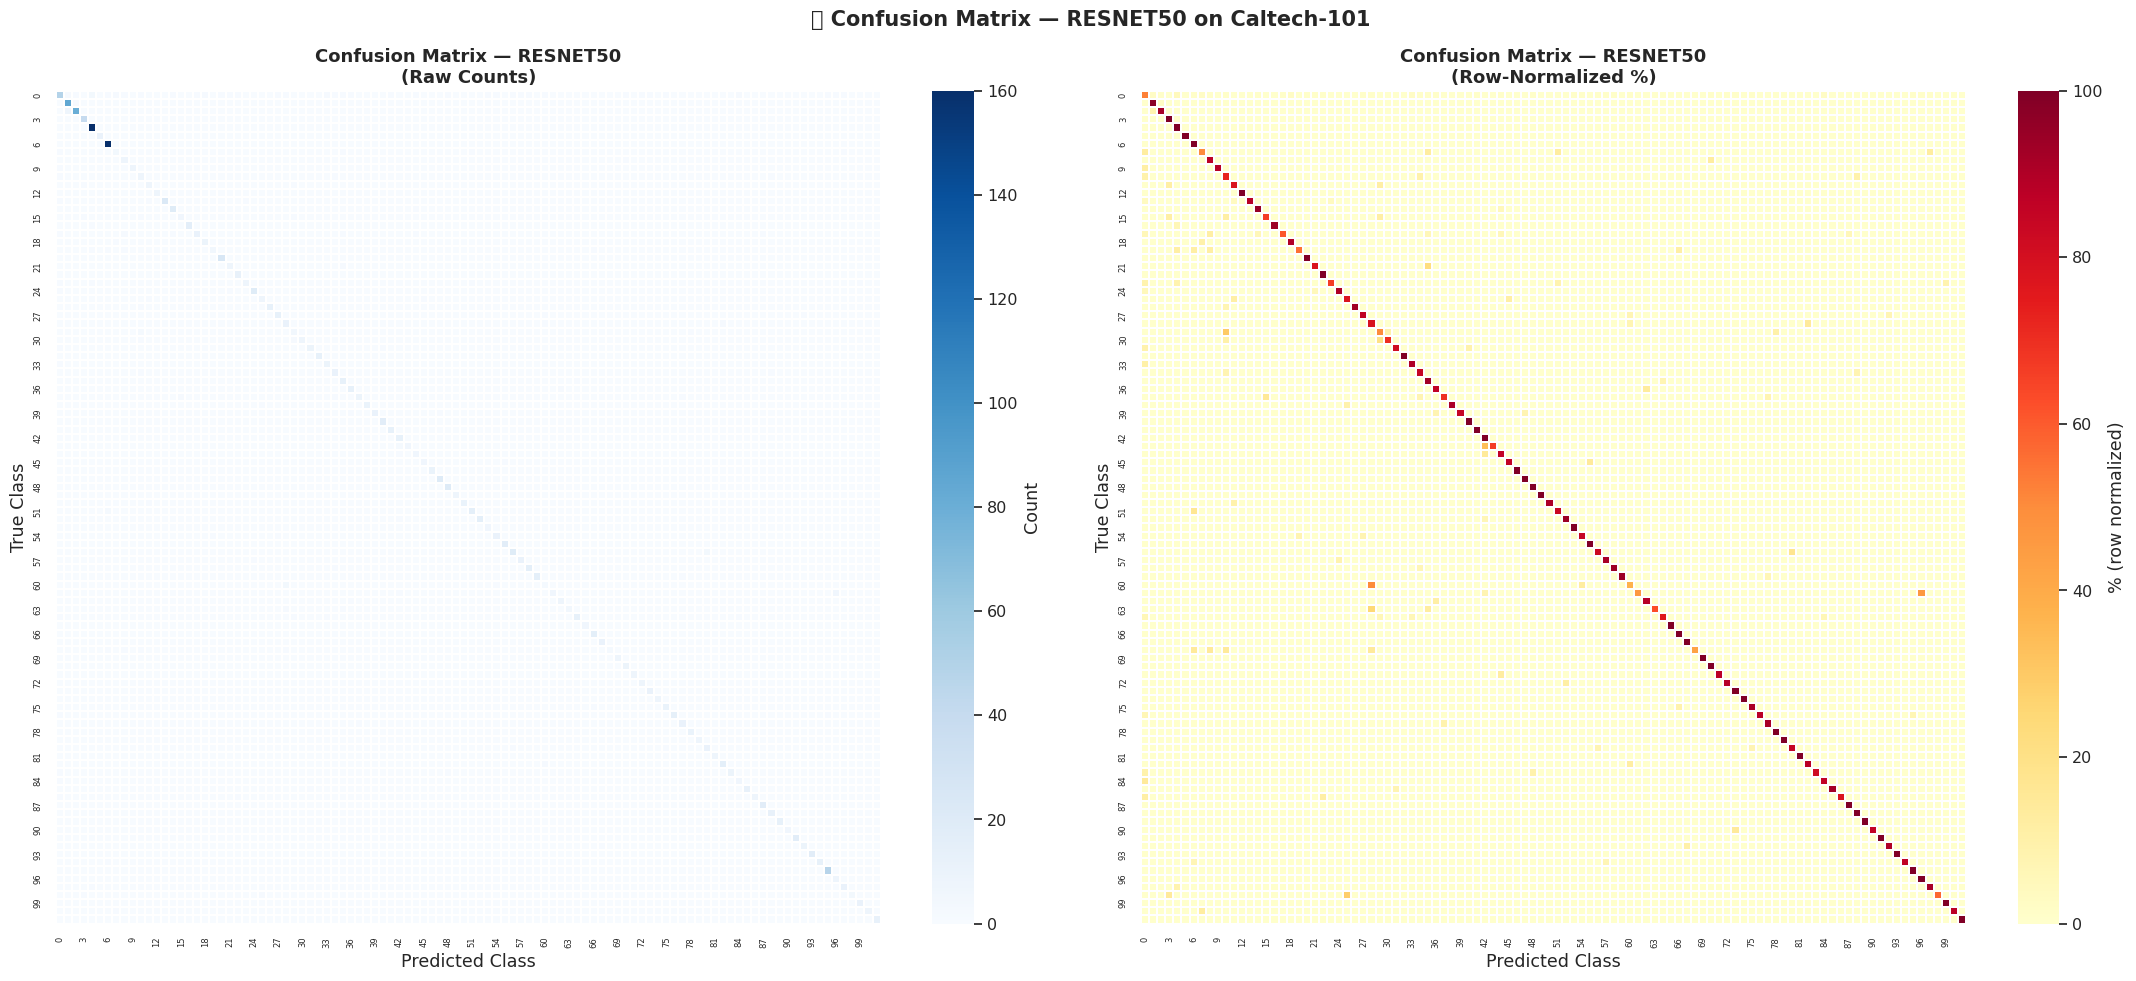

💾 Saved: 02_confusion_matrix_resnet50.png


In [8]:
# ── Confusion matrix for the BEST model (ResNet50) ────────────────────────
best_model = df_summary['Accuracy'].idxmax()
print(f'Best model: {best_model}')

r      = KNN_RESULTS[best_model]
cm     = confusion_matrix(r['y_true'], r['y_pred'])
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # row %

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Raw count
sns.heatmap(cm, ax=axes[0], cmap='Blues',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label':'Count'})
axes[0].set_title(f'Confusion Matrix — {best_model.upper()}\n(Raw Counts)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')
axes[0].tick_params(axis='both', labelsize=6)

# Percentage (normalized per row)
sns.heatmap(cm_pct, ax=axes[1], cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            vmin=0, vmax=100,
            cbar_kws={'label':'% (row normalized)'},
            fmt='.0f', annot=(N_CLASSES <= 30))
axes[1].set_title(f'Confusion Matrix — {best_model.upper()}\n(Row-Normalized %)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')
axes[1].tick_params(axis='both', labelsize=6)

plt.suptitle(f'✅ Confusion Matrix — {best_model.upper()} on Caltech-101',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/02_confusion_matrix_{best_model}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Saved: 02_confusion_matrix_{best_model}.png')

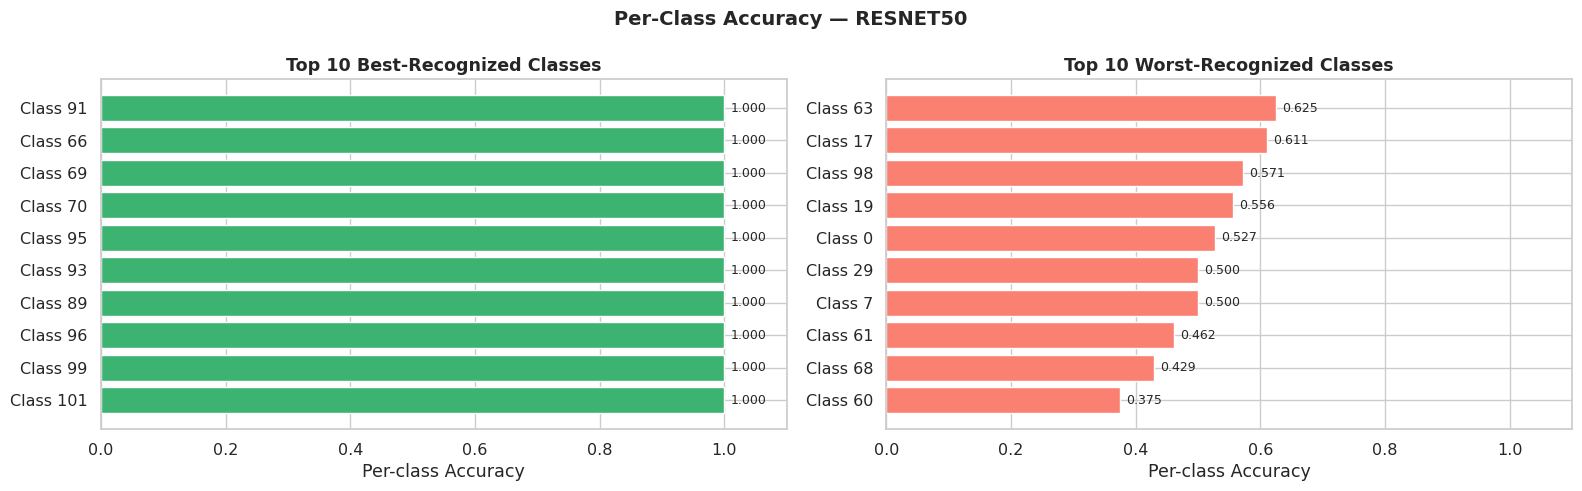

💾 Saved: 03_per_class_accuracy.png


In [9]:
# ── Diagonal accuracy (per-class) for best model ──────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Top 10 best and worst classes
top10_best  = np.argsort(per_class_acc)[-10:][::-1]
top10_worst = np.argsort(per_class_acc)[:10]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(range(10), per_class_acc[top10_best],
             color='mediumseagreen', edgecolor='white')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([f'Class {i}' for i in top10_best])
axes[0].set_title('Top 10 Best-Recognized Classes', fontweight='bold')
axes[0].set_xlabel('Per-class Accuracy')
axes[0].set_xlim(0, 1.1)
for i, v in enumerate(per_class_acc[top10_best]):
    axes[0].text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(range(10), per_class_acc[top10_worst],
             color='salmon', edgecolor='white')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'Class {i}' for i in top10_worst])
axes[1].set_title('Top 10 Worst-Recognized Classes', fontweight='bold')
axes[1].set_xlabel('Per-class Accuracy')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(per_class_acc[top10_worst]):
    axes[1].text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle(f'Per-Class Accuracy — {best_model.upper()}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 03_per_class_accuracy.png')

---
## Step 6 — Metric 3: F1 Score (Macro & Per-Class)

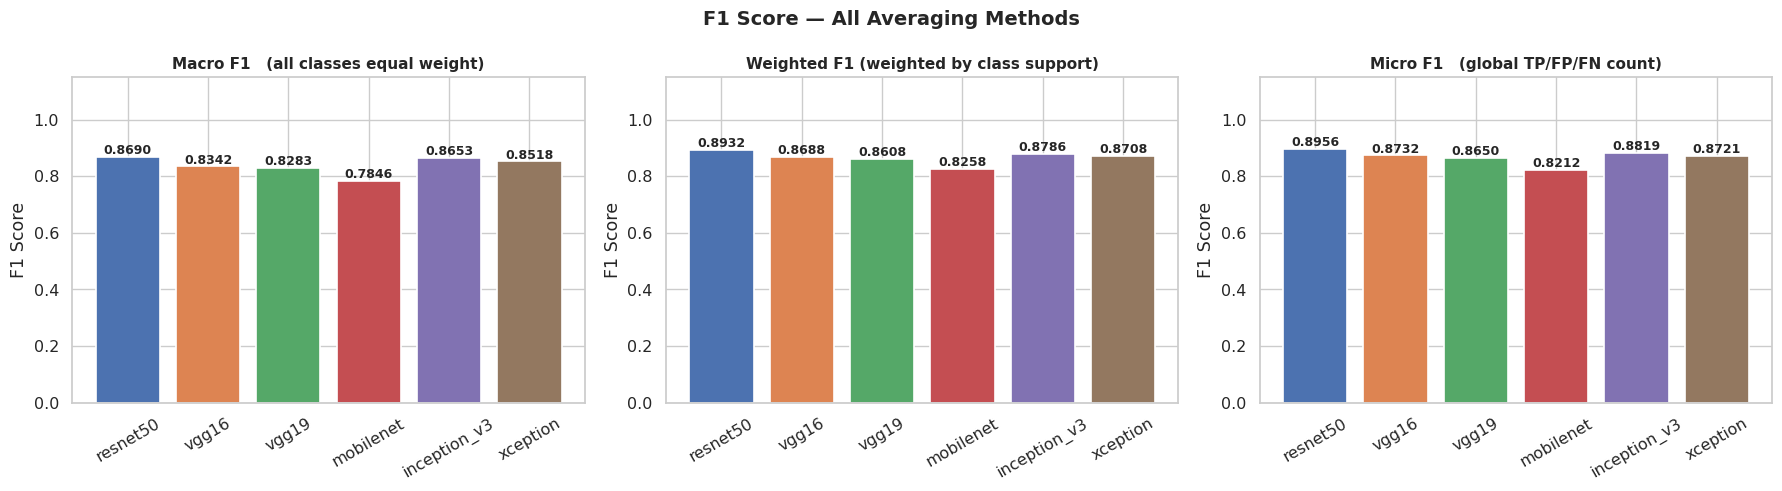

💾 Saved: 04_f1_scores.png


In [10]:
# ── F1 comparison across all models ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, avg, title in [
    (axes[0], 'macro',    'Macro F1   (all classes equal weight)'),
    (axes[1], 'weighted', 'Weighted F1 (weighted by class support)'),
    (axes[2], 'micro',    'Micro F1   (global TP/FP/FN count)'),
]:
    vals  = [f1_score(KNN_RESULTS[n]['y_true'],
                      KNN_RESULTS[n]['y_pred'],
                      average=avg, zero_division=0)
             for n in MODEL_NAMES]
    bars  = ax.bar(MODEL_NAMES, vals, color=COLORS,
                   edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('F1 Score — All Averaging Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 04_f1_scores.png')

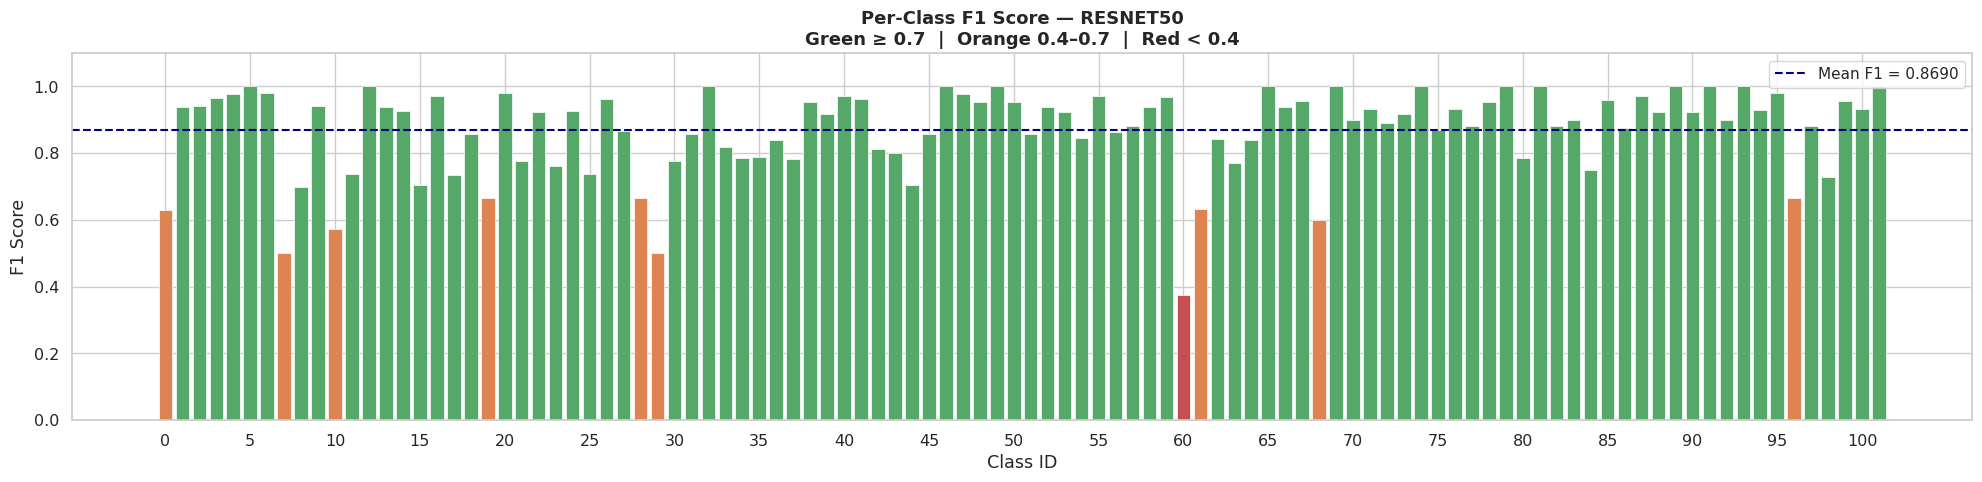

💾 Saved: 05_per_class_f1.png


In [11]:
# ── Per-class F1 for best model ───────────────────────────────────────────
r  = KNN_RESULTS[best_model]
f1_per_class = f1_score(r['y_true'], r['y_pred'],
                         average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(20, 5))
colors  = ['#55A868' if v >= 0.7 else
           '#DD8452' if v >= 0.4 else
           '#C44E52' for v in f1_per_class]

ax.bar(range(len(f1_per_class)), f1_per_class,
       color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(f1_per_class), color='navy',
           linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {np.mean(f1_per_class):.4f}')
ax.set_title(f'Per-Class F1 Score — {best_model.upper()}\n'
             f'Green ≥ 0.7  |  Orange 0.4–0.7  |  Red < 0.4',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Class ID')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.set_xticks(range(0, N_CLASSES, 5))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 05_per_class_f1.png')

---
## Step 7 — Metric 4: Precision@K · Recall@K · F1@K

In [12]:
def retrieval_metrics_at_k(features, class_ids, k_values=[1,3,5,10,20],
                            n_queries=500):
    """Compute Precision@K, Recall@K, F1@K for retrieval system."""
    feats = features.astype('float32')
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)

    index = faiss.IndexFlatIP(feats.shape[1])
    index.add(feats)

    np.random.seed(42)
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    _, I  = index.search(feats[q_idx], max(k_values) + 1)

    results = {}
    for k in k_values:
        prec_list, rec_list, f1_list = [], [], []
        for qi, q in enumerate(q_idx):
            retrieved   = [class_ids[I[qi, r]] for r in range(1, k+1)]
            q_label     = class_ids[q]
            # total same-class images (excluding query itself)
            total_rel   = np.sum(class_ids == q_label) - 1

            tp   = sum(1 for c in retrieved if c == q_label)
            p    = tp / k
            r    = tp / max(total_rel, 1)
            f1   = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

            prec_list.append(p)
            rec_list.append(r)
            f1_list.append(f1)

        results[k] = {
            'P@K':  round(np.mean(prec_list), 4),
            'R@K':  round(np.mean(rec_list),  4),
            'F1@K': round(np.mean(f1_list),   4),
        }
    return results


K_VALUES = [1, 3, 5, 10, 20]
RETRIEVAL_METRICS = {}

print('🔄 Computing Precision@K · Recall@K · F1@K ...\n')
for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    res = retrieval_metrics_at_k(ALL_FEATURES[name], CLASS_IDS, K_VALUES)
    RETRIEVAL_METRICS[name] = res
    print('  '.join(f'F1@{k}={v["F1@K"]:.4f}' for k,v in res.items()))

print('\n✅ Done')

🔄 Computing Precision@K · Recall@K · F1@K ...

  resnet50 ... F1@1=0.0188  F1@3=0.0540  F1@5=0.0850  F1@10=0.1531  F1@20=0.2541
  vgg16 ... F1@1=0.0183  F1@3=0.0506  F1@5=0.0795  F1@10=0.1399  F1@20=0.2261
  vgg19 ... F1@1=0.0183  F1@3=0.0501  F1@5=0.0796  F1@10=0.1422  F1@20=0.2312
  mobilenet ... F1@1=0.0170  F1@3=0.0447  F1@5=0.0693  F1@10=0.1182  F1@20=0.1864
  inception_v3 ... F1@1=0.0182  F1@3=0.0516  F1@5=0.0826  F1@10=0.1474  F1@20=0.2451
  xception ... F1@1=0.0185  F1@3=0.0517  F1@5=0.0815  F1@10=0.1470  F1@20=0.2442

✅ Done


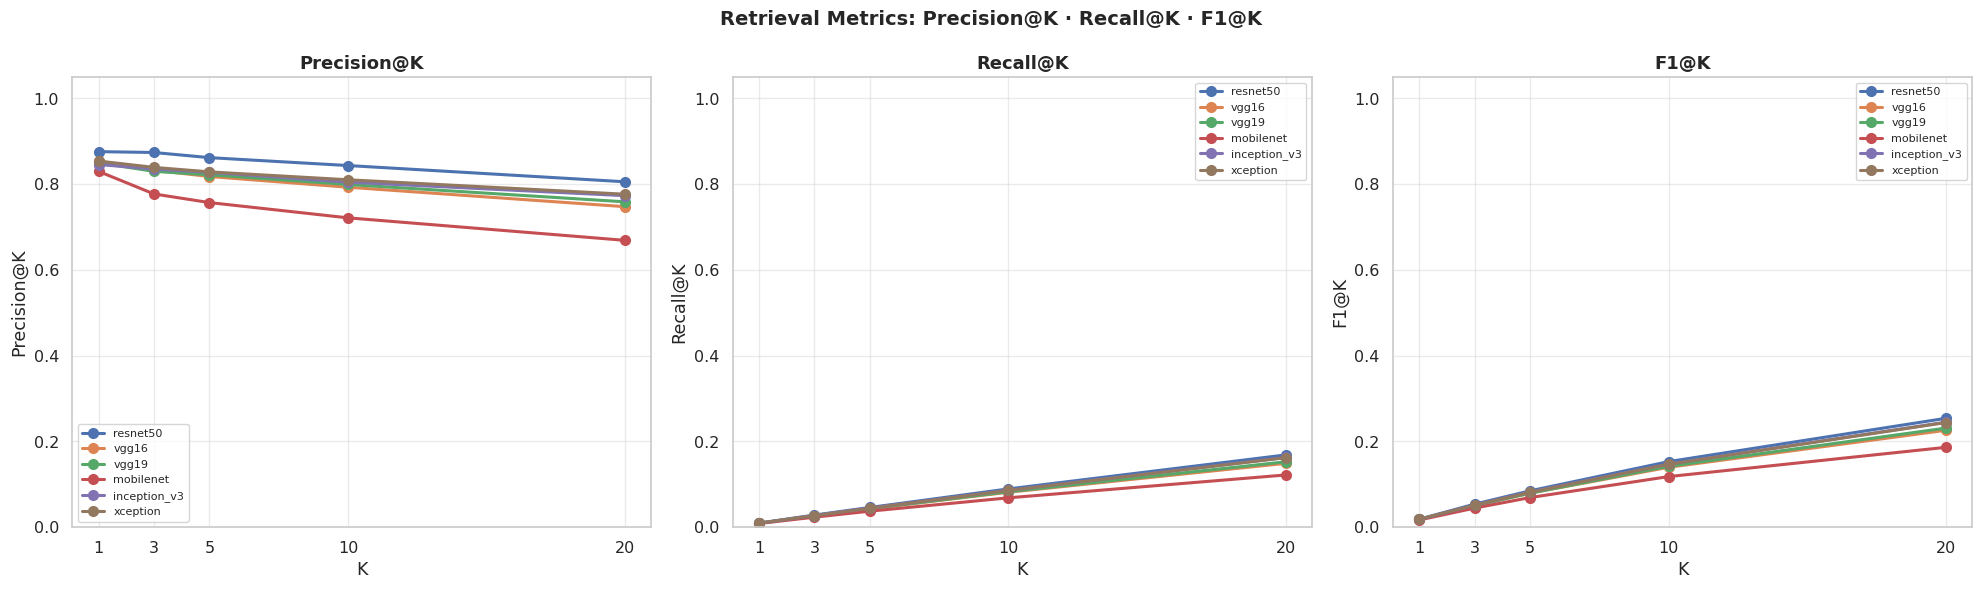

💾 Saved: 06_retrieval_prf_curves.png


In [13]:
# ── Plot: P@K / R@K / F1@K curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric_key, title, ylabel in [
    (axes[0], 'P@K',  'Precision@K', 'Precision@K'),
    (axes[1], 'R@K',  'Recall@K',    'Recall@K'),
    (axes[2], 'F1@K', 'F1@K',        'F1@K'),
]:
    for name, color in zip(MODEL_NAMES, COLORS):
        vals = [RETRIEVAL_METRICS[name][k][metric_key] for k in K_VALUES]
        ax.plot(K_VALUES, vals, marker='o', label=name, color=color,
                linewidth=2.2, markersize=7)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.set_xticks(K_VALUES)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

plt.suptitle('Retrieval Metrics: Precision@K · Recall@K · F1@K',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/06_retrieval_prf_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 06_retrieval_prf_curves.png')

In [14]:
# ── Table: All retrieval metrics ──────────────────────────────────────────
table_rows = []
for name in MODEL_NAMES:
    row = {'Model': name}
    for k in K_VALUES:
        m = RETRIEVAL_METRICS[name][k]
        row[f'P@{k}']  = m['P@K']
        row[f'R@{k}']  = m['R@K']
        row[f'F1@{k}'] = m['F1@K']
    table_rows.append(row)

df_retrieval = pd.DataFrame(table_rows).set_index('Model')
display(df_retrieval.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format('{:.4f}')
    .set_caption('✅ Full Retrieval Metrics Table — All K Values')
)

,P@1,R@1,F1@1,P@3,R@3,F1@3,P@5,R@5,F1@5,P@10,R@10,F1@10,P@20,R@20,F1@20
Model,,,,,,,,,,,,,,,
resnet50,0.8760,0.0096,0.0188,0.8740,0.0284,0.0540,0.8620,0.0461,0.0850,0.8436,0.0894,0.1531,0.8057,0.1686,0.2541
vgg16,0.8540,0.0093,0.0183,0.8327,0.0266,0.0506,0.8180,0.0432,0.0795,0.7930,0.0816,0.1399,0.7476,0.1490,0.2261
vgg19,0.8500,0.0093,0.0183,0.8300,0.0264,0.0501,0.8220,0.0432,0.0796,0.7994,0.0829,0.1422,0.7589,0.1526,0.2312
mobilenet,0.8300,0.0087,0.0170,0.7773,0.0235,0.0447,0.7572,0.0375,0.0693,0.7216,0.0686,0.1182,0.6691,0.1219,0.1864
inception_v3,0.8460,0.0093,0.0182,0.8353,0.0272,0.0516,0.8276,0.0449,0.0826,0.8048,0.0862,0.1474,0.7733,0.1627,0.2451
xception,0.8540,0.0094,0.0185,0.8393,0.0272,0.0517,0.8288,0.0442,0.0815,0.8104,0.0859,0.1470,0.7767,0.1621,0.2442


---
## Step 8 — Metric 5: MAP (Mean Average Precision)

In [15]:
def compute_map(features, class_ids, n_queries=300, max_k=50):
    """
    Mean Average Precision:
    For each query, compute AP = average of precision values
    at each K where a relevant item is retrieved.
    MAP = mean of AP across all queries.
    """
    feats = features.astype('float32')
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)

    index = faiss.IndexFlatIP(feats.shape[1])
    index.add(feats)

    np.random.seed(42)
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    _, I  = index.search(feats[q_idx], max_k + 1)

    ap_list = []
    for qi, q in enumerate(q_idx):
        q_label   = class_ids[q]
        retrieved = [class_ids[I[qi, r]] for r in range(1, max_k+1)]

        hits, prec_sum = 0, 0.0
        for rank, label in enumerate(retrieved, 1):
            if label == q_label:
                hits      += 1
                prec_sum  += hits / rank

        total_rel = max(np.sum(class_ids == q_label) - 1, 1)
        ap_list.append(prec_sum / min(total_rel, max_k))

    return round(np.mean(ap_list), 4)


MAP_SCORES = {}
print('🔄 Computing MAP (Mean Average Precision) ...\n')
for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    score = compute_map(ALL_FEATURES[name], CLASS_IDS)
    MAP_SCORES[name] = score
    print(f'MAP = {score:.4f}')

print('\n✅ Done')

🔄 Computing MAP (Mean Average Precision) ...

  resnet50 ... MAP = 0.6429
  vgg16 ... MAP = 0.5741
  vgg19 ... MAP = 0.5796
  mobilenet ... MAP = 0.4854
  inception_v3 ... MAP = 0.6148
  xception ... MAP = 0.6218

✅ Done


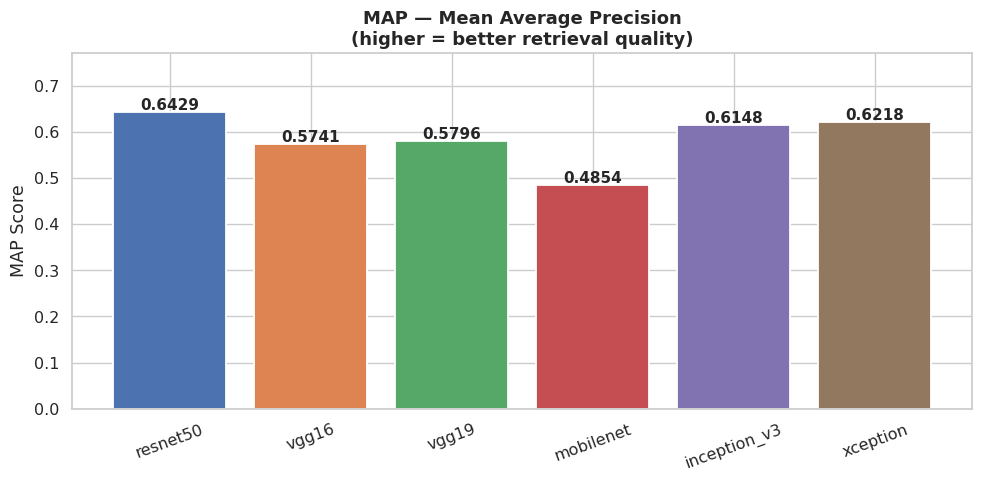

💾 Saved: 07_map_scores.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
vals    = [MAP_SCORES[n] for n in MODEL_NAMES]
bars    = ax.bar(MODEL_NAMES, vals, color=COLORS,
                 edgecolor='white', linewidth=1.3)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('MAP — Mean Average Precision\n(higher = better retrieval quality)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('MAP Score')
ax.set_ylim(0, max(vals)*1.2)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/07_map_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 07_map_scores.png')

---
## Step 9 — Metric 6: MRR (Mean Reciprocal Rank)

In [17]:
def compute_mrr(features, class_ids, n_queries=500, max_k=20):
    """
    Mean Reciprocal Rank:
    MRR = mean of (1 / rank_of_first_correct_result).
    If first correct at rank 1 → 1/1=1.0 (perfect)
    If first correct at rank 5 → 1/5=0.2
    """
    feats = features.astype('float32')
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)

    index = faiss.IndexFlatIP(feats.shape[1])
    index.add(feats)

    np.random.seed(42)
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    _, I  = index.search(feats[q_idx], max_k + 1)

    rr_list = []
    for qi, q in enumerate(q_idx):
        q_label   = class_ids[q]
        rr        = 0.0
        for rank in range(1, max_k+1):
            if class_ids[I[qi, rank]] == q_label:
                rr = 1.0 / rank
                break
        rr_list.append(rr)

    return round(np.mean(rr_list), 4)


MRR_SCORES = {}
print('🔄 Computing MRR (Mean Reciprocal Rank) ...\n')
for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    score = compute_mrr(ALL_FEATURES[name], CLASS_IDS)
    MRR_SCORES[name] = score
    print(f'MRR = {score:.4f}')

print('\n✅ Done')

🔄 Computing MRR (Mean Reciprocal Rank) ...

  resnet50 ... MRR = 0.9146
  vgg16 ... MRR = 0.8981
  vgg19 ... MRR = 0.8962
  mobilenet ... MRR = 0.8742
  inception_v3 ... MRR = 0.8942
  xception ... MRR = 0.8947

✅ Done


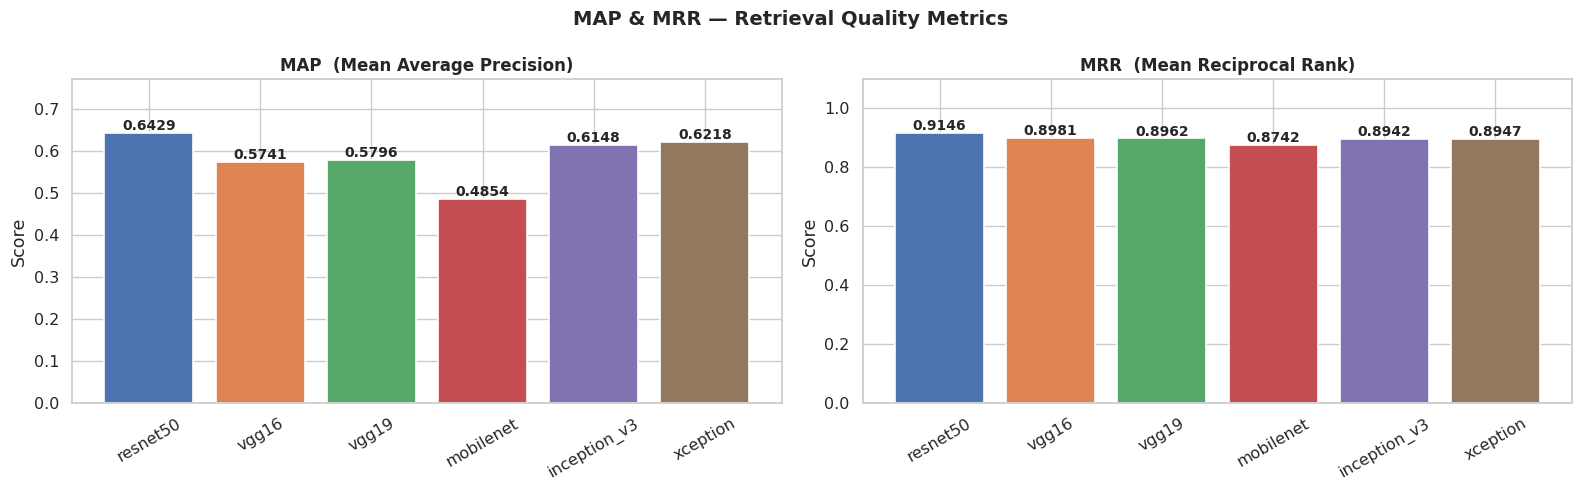

💾 Saved: 08_map_mrr.png


In [18]:
# ── MAP + MRR side by side ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, scores, title in [
    (axes[0], MAP_SCORES, 'MAP  (Mean Average Precision)'),
    (axes[1], MRR_SCORES, 'MRR  (Mean Reciprocal Rank)'),
]:
    vals = [scores[n] for n in MODEL_NAMES]
    bars = ax.bar(MODEL_NAMES, vals, color=COLORS,
                  edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(vals)*1.2)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('MAP & MRR — Retrieval Quality Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/08_map_mrr.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 08_map_mrr.png')

---
## Step 10 — Metric 7: ROC Curve & AUC (One-vs-Rest)

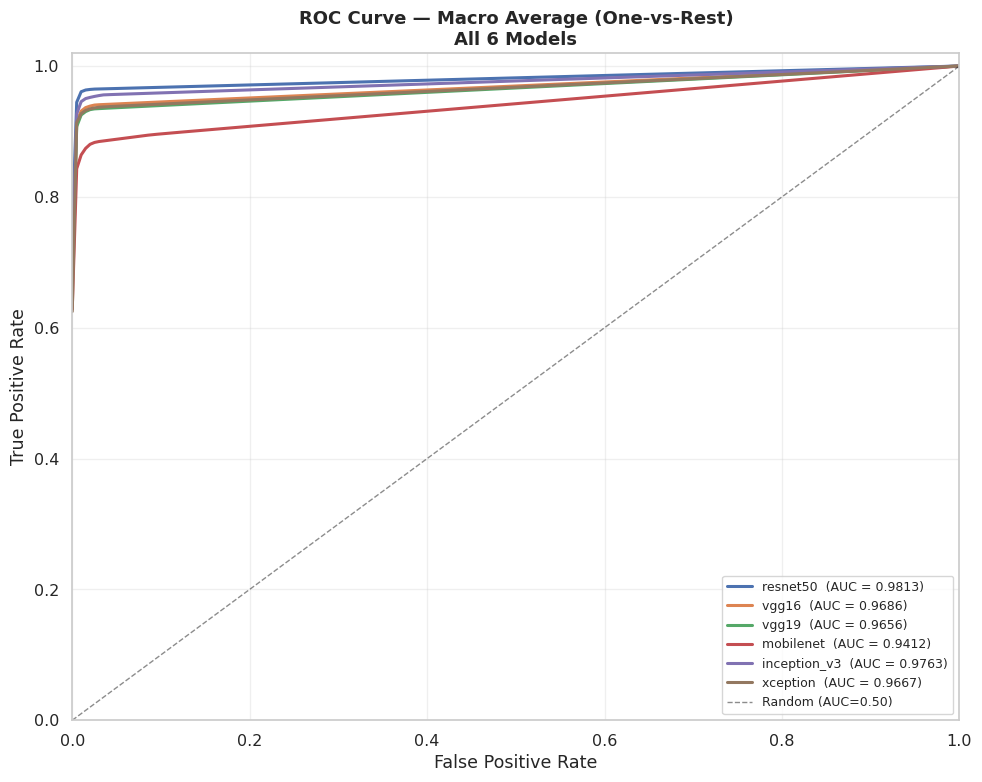

💾 Saved: 09_roc_curves.png

AUC Scores:
  resnet50       : 0.9813
  vgg16          : 0.9686
  vgg19          : 0.9656
  mobilenet      : 0.9412
  inception_v3   : 0.9763
  xception       : 0.9667


In [19]:
# ── Macro-average ROC for all models ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

auc_scores = {}
for name, color in zip(MODEL_NAMES, COLORS):
    r       = KNN_RESULTS[name]
    classes = r['classes']
    n_cls   = len(classes)

    # Binarize labels
    y_true_bin = label_binarize(r['y_true'], classes=classes)
    y_proba    = r['y_proba']

    # Compute ROC for each class, then macro average
    fpr_all, tpr_all = [], []
    for i in range(n_cls):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        fpr_all.append(fpr)
        tpr_all.append(tpr)

    # Interpolate to common FPR grid
    mean_fpr  = np.linspace(0, 1, 200)
    mean_tpr  = np.mean([np.interp(mean_fpr, f, t)
                         for f, t in zip(fpr_all, tpr_all)], axis=0)
    mean_auc  = auc(mean_fpr, mean_tpr)
    auc_scores[name] = round(mean_auc, 4)

    ax.plot(mean_fpr, mean_tpr, linewidth=2.2, color=color,
            label=f'{name}  (AUC = {mean_auc:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')
ax.set_title('ROC Curve — Macro Average (One-vs-Rest)\nAll 6 Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 09_roc_curves.png')
print('\nAUC Scores:')
for n, v in auc_scores.items():
    print(f'  {n:15s}: {v:.4f}')

---
## Step 11 — Metric 8: Precision-Recall Curve

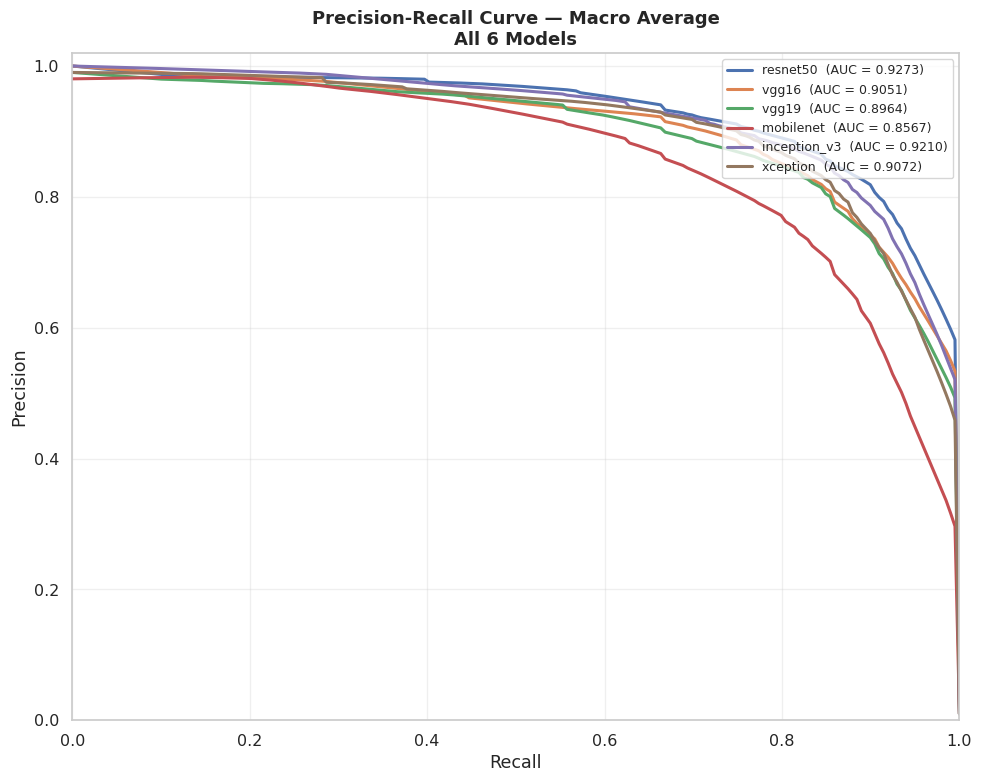

💾 Saved: 10_pr_curves.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc_scores = {}
for name, color in zip(MODEL_NAMES, COLORS):
    r          = KNN_RESULTS[name]
    classes    = r['classes']
    y_true_bin = label_binarize(r['y_true'], classes=classes)
    y_proba    = r['y_proba']

    # Macro-average PR curve
    prec_all, rec_all = [], []
    for i in range(len(classes)):
        if y_true_bin[:, i].sum() == 0:
            continue
        p, r_vals, _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        prec_all.append(p)
        rec_all.append(r_vals)

    mean_rec  = np.linspace(0, 1, 200)
    mean_prec = np.mean([np.interp(mean_rec, rc[::-1], pr[::-1])
                         for pr, rc in zip(prec_all, rec_all)], axis=0)
    pr_auc    = auc(mean_rec, mean_prec)
    pr_auc_scores[name] = round(pr_auc, 4)

    ax.plot(mean_rec, mean_prec, linewidth=2.2, color=color,
            label=f'{name}  (AUC = {pr_auc:.4f})')

ax.set_title('Precision-Recall Curve — Macro Average\nAll 6 Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/10_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 10_pr_curves.png')

---
## Step 12 — Metric 9: Top-K Accuracy

In [21]:
TOP_K_VALUES = [1, 3, 5, 10]
TOPK_ACC     = {}

print('🔄 Computing Top-K Accuracy ...\n')
for name in MODEL_NAMES:
    r    = KNN_RESULTS[name]
    accs = {}
    for k in TOP_K_VALUES:
        acc = top_k_accuracy_score(
            r['y_true'], r['y_proba'], k=k,
            labels=r['classes']
        )
        accs[k] = round(acc, 4)
    TOPK_ACC[name] = accs
    print(f'  {name:15s}  ' +
          '  '.join(f'Top-{k}={v:.4f}' for k,v in accs.items()))

df_topk = pd.DataFrame(TOPK_ACC).T
df_topk.columns   = [f'Top-{k} Acc' for k in TOP_K_VALUES]
df_topk.index.name = 'Model'

display(df_topk.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format('{:.4f}')
    .set_caption('Top-K Accuracy — KNN Classifier')
)

🔄 Computing Top-K Accuracy ...

  resnet50         Top-1=0.8917  Top-3=0.9486  Top-5=0.9650  Top-10=0.9656
  vgg16            Top-1=0.8671  Top-3=0.9371  Top-5=0.9497  Top-10=0.9513
  vgg19            Top-1=0.8606  Top-3=0.9262  Top-5=0.9448  Top-10=0.9453
  mobilenet        Top-1=0.8223  Top-3=0.8846  Top-5=0.9142  Top-10=0.9158
  inception_v3     Top-1=0.8742  Top-3=0.9459  Top-5=0.9634  Top-10=0.9645
  xception         Top-1=0.8677  Top-3=0.9366  Top-5=0.9442  Top-10=0.9470


,Top-1 Acc,Top-3 Acc,Top-5 Acc,Top-10 Acc
Model,,,,
resnet50,0.8917,0.9486,0.9650,0.9656
vgg16,0.8671,0.9371,0.9497,0.9513
vgg19,0.8606,0.9262,0.9448,0.9453
mobilenet,0.8223,0.8846,0.9142,0.9158
inception_v3,0.8742,0.9459,0.9634,0.9645
xception,0.8677,0.9366,0.9442,0.9470


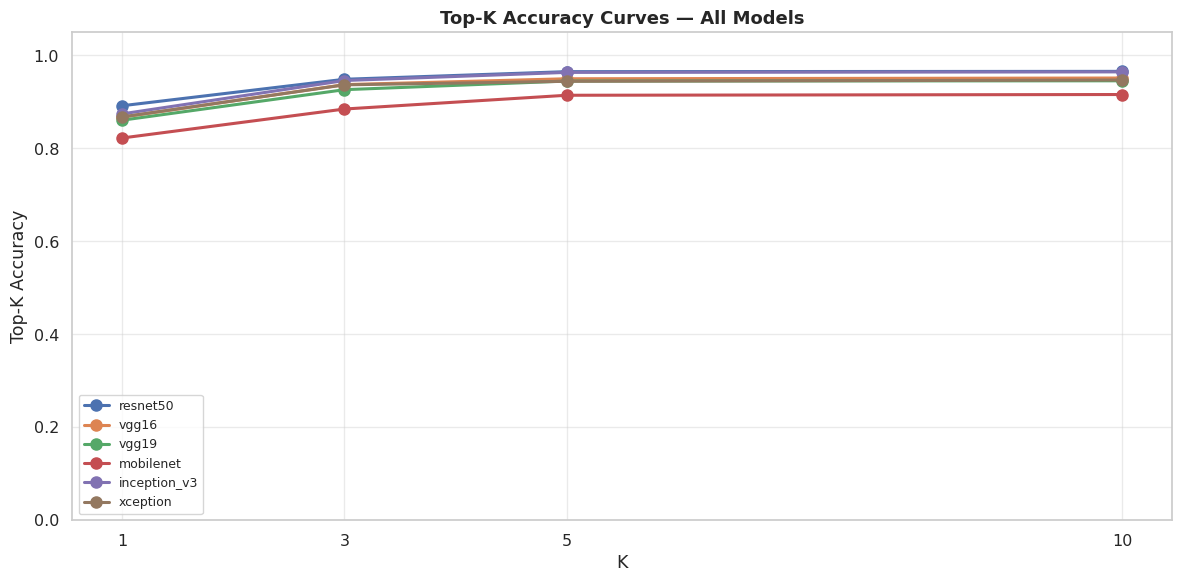

💾 Saved: 11_topk_accuracy.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, color in zip(MODEL_NAMES, COLORS):
    vals = [TOPK_ACC[name][k] for k in TOP_K_VALUES]
    ax.plot(TOP_K_VALUES, vals, marker='o', label=name,
            color=color, linewidth=2.2, markersize=8)

ax.set_title('Top-K Accuracy Curves — All Models',
             fontsize=13, fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Top-K Accuracy')
ax.set_xticks(TOP_K_VALUES)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/11_topk_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: 11_topk_accuracy.png')

---
## Step 13 — Complete Summary Dashboard

In [23]:
final_rows = []
for name in MODEL_NAMES:
    final_rows.append({
        'Model':           name,
        'Accuracy':        KNN_RESULTS[name]['accuracy'],
        'Macro F1':        f1_score(KNN_RESULTS[name]['y_true'],
                                    KNN_RESULTS[name]['y_pred'],
                                    average='macro', zero_division=0),
        'Macro Recall':    recall_score(KNN_RESULTS[name]['y_true'],
                                        KNN_RESULTS[name]['y_pred'],
                                        average='macro', zero_division=0),
        'Macro Precision': precision_score(KNN_RESULTS[name]['y_true'],
                                            KNN_RESULTS[name]['y_pred'],
                                            average='macro', zero_division=0),
        'MAP':             MAP_SCORES[name],
        'MRR':             MRR_SCORES[name],
        'ROC-AUC':         auc_scores.get(name, 0),
        'PR-AUC':          pr_auc_scores.get(name, 0),
        'P@5':             RETRIEVAL_METRICS[name][5]['P@K'],
        'R@5':             RETRIEVAL_METRICS[name][5]['R@K'],
        'F1@5':            RETRIEVAL_METRICS[name][5]['F1@K'],
        'Top-5 Acc':       TOPK_ACC[name][5],
    })

df_final = pd.DataFrame(final_rows).set_index('Model').round(4)
df_final = df_final.sort_values('Macro F1', ascending=False)
df_final.index.name = 'Model'

print('\n=== ✅ COMPLETE PERFORMANCE METRICS TABLE ===')
display(df_final.style
    .background_gradient(subset=['Accuracy','Macro F1','MAP','MRR','ROC-AUC'],
                         cmap='RdYlGn', axis=None)
    .format('{:.4f}')
    .set_caption('🏆 All Performance Metrics — AI Visual Search — Caltech-101')
)


=== ✅ COMPLETE PERFORMANCE METRICS TABLE ===


,Accuracy,Macro F1,Macro Recall,Macro Precision,MAP,MRR,ROC-AUC,PR-AUC,P@5,R@5,F1@5,Top-5 Acc
Model,,,,,,,,,,,,
resnet50,0.8956,0.8690,0.8730,0.8822,0.6429,0.9146,0.9813,0.9273,0.8620,0.0461,0.0850,0.9650
inception_v3,0.8819,0.8653,0.8724,0.8717,0.6148,0.8942,0.9763,0.9210,0.8276,0.0449,0.0826,0.9634
xception,0.8721,0.8518,0.8547,0.8655,0.6218,0.8947,0.9667,0.9072,0.8288,0.0442,0.0815,0.9442
vgg16,0.8732,0.8342,0.8400,0.8581,0.5741,0.8981,0.9686,0.9051,0.8180,0.0432,0.0795,0.9497
vgg19,0.8650,0.8283,0.8346,0.8474,0.5796,0.8962,0.9656,0.8964,0.8220,0.0432,0.0796,0.9448
mobilenet,0.8212,0.7846,0.7600,0.8648,0.4854,0.8742,0.9412,0.8567,0.7572,0.0375,0.0693,0.9142


In [24]:
# ── Save all results ──────────────────────────────────────────────────────
df_final.to_csv(    f'{RESULTS_DIR}/complete_metrics.csv')
df_retrieval.to_csv(f'{RESULTS_DIR}/retrieval_metrics.csv')
df_topk.to_csv(     f'{RESULTS_DIR}/topk_accuracy.csv')

print('✅ All metrics saved to:', RESULTS_DIR)
print()
for f in sorted(os.listdir(RESULTS_DIR)):
    kb = os.path.getsize(f'{RESULTS_DIR}/{f}') / 1024
    print(f'  {f:40s}  {kb:.1f} KB')

# Final winner
best = df_final['Macro F1'].idxmax()
print(f'\n🏆 Best Model (Macro F1): {best.upper()}')
print(f'   F1      = {df_final.loc[best,"Macro F1"]:.4f}')
print(f'   MAP     = {df_final.loc[best,"MAP"]:.4f}')
print(f'   MRR     = {df_final.loc[best,"MRR"]:.4f}')
print(f'   ROC-AUC = {df_final.loc[best,"ROC-AUC"]:.4f}')

✅ All metrics saved to: /content/drive/MyDrive/metrics

  01_all_metrics.png                        77.2 KB
  02_confusion_matrix_resnet50.png          130.8 KB
  03_per_class_accuracy.png                 108.7 KB
  04_f1_scores.png                          98.4 KB
  05_per_class_f1.png                       63.9 KB
  06_retrieval_prf_curves.png               152.7 KB
  07_map_scores.png                         71.0 KB
  08_map_mrr.png                            99.7 KB
  09_roc_curves.png                         122.3 KB
  10_pr_curves.png                          145.0 KB
  11_topk_accuracy.png                      66.1 KB
  complete_metrics.csv                      0.6 KB
  retrieval_metrics.csv                     0.7 KB
  topk_accuracy.csv                         0.3 KB

🏆 Best Model (Macro F1): RESNET50
   F1      = 0.8690
   MAP     = 0.6429
   MRR     = 0.9146
   ROC-AUC = 0.9813
